# Converting [WP5304](https://identifiers.org/wikipathways/WP5304_r141099) into a biolink property graph.

Each conversion starts from one WikiPathways record type.

In [1]:
import os
import urllib.request
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from IPython.display import Markdown, display
from rdfsolve.api import Client
from rdfsolve.property_graph import PropertyGraph, Identity
from rdfsolve.conversion import Profile, Rule, Biolink, write_query, within, to_kgx

In [2]:
schema_wp = "../data"
biolink_profile = Path("../data")
wp_rdf = Path("../data/wikipathways-20260810-rdf-wp.zip")
if not wp_rdf.exists():
    urllib.request.urlretrieve("https://data.wikipathways.org/20260810/rdf/wikipathways-20260810-rdf-wp.zip", wp_rdf)
wp = Client.open(schema=f"{schema_wp}/wikipathways.schema.json", data_file=wp_rdf)
biolink = Biolink.read(path=biolink_profile / "biolink-model-4.4.5.yaml")

PATHWAY = "WP5304"

In [3]:
generated_queries = Path("output/queries")
generated_queries.mkdir(parents=True, exist_ok=True)


def save(name, title, description, rules, focus_as=None):
    """Write the rules as the query file wikipathways-biolink-<name>.rq and show it."""
    text = write_query(rules=rules, title=title, description=description, source=wp, target=biolink, focus_as=focus_as)
    path = generated_queries / f"wikipathways-biolink-{name}.rq"
    path.write_text(text)
    print(text)

## Load pathway in the rdfsolve client

In [4]:
pathway = wp.find(text=PATHWAY, kind="Pathway")
pathway.paths(incoming=True)

,From,Link,To
0,Pathway,Is part of,Publication Xref
1,Pathway,participants,Binding
2,Pathway,source,Binding
3,Pathway,target,Binding
4,Pathway,Is part of,Binding
...,...,...,...
56,Pathway,participants,Transcription Translation
57,Pathway,source,Transcription Translation
58,Pathway,Is part of,Transcription Translation
59,Pathway,Is part of,Translocation


## Proteins

In [5]:
display(Markdown(wp.diagram(kind="Protein", links=[])))

```mermaid
flowchart LR
C0("`**Protein**
wp:Protein`")
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [6]:
display(Markdown(biolink.diagram(terms=["biolink:Protein"])))

```mermaid
flowchart LR
B0("`**protein**
ids: UniProtKB, PR, ENSEMBL, FB, UMLS, NCIT`")
style B0 fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
B1("`**polypeptide**`")
B2("`**biological entity**`")
B3("`**gene product mixin**
mixin`")
style B3 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B0 -->|"is a"| B1
B1 -->|"is a"| B2
B0 -.->|"mixin"| B3
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [7]:
proteins = [
    Rule.between(client=wp, focus="Protein", predicate="a", value="biolink:Protein"),
]
save(name="proteins", title="Proteins", description="A node drawn as a protein is a Biolink Protein.", rules=proteins)

# title: Proteins
# description: A node drawn as a protein is a Biolink Protein.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?protein a biolink:Protein .
}
WHERE {
  ?protein a wp:Protein .
}



## Gene products

In [8]:
display(Markdown(wp.diagram(kind="Gene Product", links=["BridgeDb Ensembl link", "BridgeDb Entrez Gene link"])))

```mermaid
flowchart LR
C0("`**Gene Product**
wp:GeneProduct`")
C1("`**3 other types**
Rna, Complex, Pathway`")
style C1 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C2("`**Data Node**
wp:DataNode`")
C3("`**IRI**`")
C4("`**Protein**
wp:Protein`")
C5("`**2 other types**
Rna, Complex`")
style C5 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C0 -.->|"`BridgeDb Ensembl link (448)`"| C1
C0 -->|"`BridgeDb Ensembl link (25,137)`"| C2
C0 -->|"`BridgeDb Ensembl link (25,060)`"| C0
C0 -->|"`BridgeDb Ensembl link (14,000)`"| C3
C0 -->|"`BridgeDb Ensembl link (1,803)`"| C4
C0 -.->|"`BridgeDb Entrez Gene link (858)`"| C5
C0 -->|"`BridgeDb Entrez Gene link (23,352)`"| C2
C0 -->|"`BridgeDb Entrez Gene link (22,891)`"| C0
C0 -->|"`BridgeDb Entrez Gene link (14,009)`"| C3
C0 -->|"`BridgeDb Entrez Gene link (2,853)`"| C4
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [9]:
display(Markdown(biolink.diagram(terms=["biolink:Gene"])))

```mermaid
flowchart LR
B0("`**gene**
ids: NCBIGene, ENSEMBL, HGNC, MGI, ZFIN, dictyBase`")
style B0 fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
B1("`**biological entity**`")
B2("`**named thing**`")
B3("`**gene or gene product**
mixin`")
style B3 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B4("`**gene or gene product or gene family**
mixin`")
style B4 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B5("`**genomic entity**
mixin`")
style B5 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B6("`**chemical entity or gene or gene product**
mixin`")
style B6 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B7("`**physical essence**
mixin`")
style B7 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B8("`**ontology class**
mixin`")
style B8 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B0 -->|"is a"| B1
B1 -->|"is a"| B2
B0 -.->|"mixin"| B3
B0 -.->|"mixin"| B4
B0 -.->|"mixin"| B5
B0 -.->|"mixin"| B6
B0 -.->|"mixin"| B7
B0 -.->|"mixin"| B8
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [10]:
gene_products = [
    Rule.between(client=wp, focus="Gene Product", predicate="a", value="biolink:Gene", exact_kind=True),
]
save(name="gene-products", title="Gene products", description="A node drawn as a gene product, and not as a protein, is drawn with a gene identifier (Ensembl, NCBI Gene): a Biolink Gene.", rules=gene_products)

# title: Gene products
# description: A node drawn as a gene product, and not as a protein, is drawn with a gene identifier (Ensembl, NCBI Gene): a Biolink Gene.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?geneproduct a biolink:Gene .
}
WHERE {
  ?geneproduct a wp:GeneProduct .
  FILTER NOT EXISTS { ?geneproduct a wp:Complex }
  FILTER NOT EXISTS { ?geneproduct a wp:Metabolite }
  FILTER NOT EXISTS { ?geneproduct a wp:Protein }
  FILTER NOT EXISTS { ?geneproduct a wp:Rna }
}



## Chemicals

In [11]:
display(Markdown(wp.diagram(kind="Metabolite", links=[])))

```mermaid
flowchart LR
C0("`**Metabolite**
wp:Metabolite`")
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [12]:
display(Markdown(biolink.diagram(terms=["biolink:ChemicalEntity"])))

```mermaid
flowchart LR
B0("`**chemical entity**
ids: CHEBI, UNII, PUBCHEM.COMPOUND, CHEMBL.COMPOUND, DRUGBANK, MESH`")
style B0 fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
B1("`**named thing**`")
B2("`**entity**`")
B3("`**physical essence**
mixin`")
style B3 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B4("`**chemical or drug or treatment**
mixin`")
style B4 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B5("`**chemical entity or gene or gene product**
mixin`")
style B5 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B6("`**chemical entity or protein or polypeptide**
mixin`")
style B6 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B0 -->|"is a"| B1
B1 -->|"is a"| B2
B0 -.->|"mixin"| B3
B0 -.->|"mixin"| B4
B0 -.->|"mixin"| B5
B0 -.->|"mixin"| B6
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [13]:
chemicals = [
    Rule.between(client=wp, focus="Metabolite", predicate="a", value="biolink:ChemicalEntity"),
]
save(name="chemicals", title="Chemicals", description="A node drawn as a metabolite is a Biolink ChemicalEntity.", rules=chemicals)

# title: Chemicals
# description: A node drawn as a metabolite is a Biolink ChemicalEntity.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?metabolite a biolink:ChemicalEntity .
}
WHERE {
  ?metabolite a wp:Metabolite .
}



## Catalysis

In [14]:
display(Markdown(wp.diagram(kind="Catalysis", links=["source", "target"])))

```mermaid
flowchart LR
C0("`**Catalysis**
wp:Catalysis`")
C1("`**3 other types**
Rna, Metabolite, Pathway`")
style C1 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C2("`**Data Node**
wp:DataNode`")
C3("`**Gene Product**
wp:GeneProduct`")
C4("`**Protein**
wp:Protein`")
C5("`**Complex**
wp:Complex`")
C6("`**9 other types**
Gene Product, Protein, Metabolite, Binding`")
style C6 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C7("`**Interaction**
wp:Interaction`")
C8("`**Directed Interaction**
wp:DirectedInteraction`")
C9("`**Conversion**
wp:Conversion`")
C0 -.->|"`source (92)`"| C1
C0 -->|"`source (4,804)`"| C2
C0 -->|"`source (3,484)`"| C3
C0 -->|"`source (1,889)`"| C4
C0 -->|"`source (348)`"| C5
C0 -.->|"`target (110)`"| C6
C0 -->|"`target (4,741)`"| C7
C0 -->|"`target (4,531)`"| C8
C0 -->|"`target (2,651)`"| C9
C0 -->|"`target (63)`"| C2
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [15]:
display(Markdown(biolink.diagram(terms=["biolink:catalyzes", "biolink:MolecularActivity"])))

```mermaid
flowchart LR
B0("`**any class**`")
B1("`**molecular activity**
ids: GO, REACT, RHEA, metacyc.reaction, EC, TCDB`")
style B1 fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
B2("`**biological process or activity**`")
B3("`**biological entity**`")
B4("`**occurrent**
mixin`")
style B4 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B5("`**ontology class**
mixin`")
style B5 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B0 ==>|"catalyzes (is a participates in)"| B0
B1 -->|"is a"| B2
B2 -->|"is a"| B3
B1 -.->|"mixin"| B4
B1 -.->|"mixin"| B5
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [16]:
catalysis = [
    Rule.between(client=wp, focus="Catalysis", predicate="biolink:catalyzes",
                 subject="source", subject_as="enzyme",
                 object="target", object_as="reaction"),
]
save(name="catalysis", title="An enzyme catalyzes a reaction", description="The source of a catalysis catalyzes its target.", rules=catalysis)

# title: An enzyme catalyzes a reaction
# description: The source of a catalysis catalyzes its target.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?enzyme biolink:catalyzes ?reaction .
}
WHERE {
  ?catalysis a wp:Catalysis .
  ?catalysis wp:source ?enzyme .
  ?catalysis wp:target ?reaction .
}



## Reaction

In [17]:
display(Markdown(wp.diagram(kind="Conversion", links=["source", "target"])))

```mermaid
flowchart LR
C0("`**Conversion**
wp:Conversion`")
C1("`**3 other types**
Rna, Pathway, Complex`")
style C1 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C2("`**Data Node**
wp:DataNode`")
C3("`**Metabolite**
wp:Metabolite`")
C4("`**Gene Product**
wp:GeneProduct`")
C5("`**Protein**
wp:Protein`")
C6("`**7 other types**
Directed Interaction, Conversion, Protein, Rna`")
style C6 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C7("`**Interaction**
wp:Interaction`")
C0 -.->|"`source (61)`"| C1
C0 -->|"`source (6,730)`"| C2
C0 -->|"`source (6,239)`"| C3
C0 -->|"`source (381)`"| C4
C0 -->|"`source (263)`"| C5
C0 -.->|"`target (727)`"| C6
C0 -->|"`target (6,722)`"| C2
C0 -->|"`target (6,244)`"| C3
C0 -->|"`target (360)`"| C4
C0 -->|"`target (226)`"| C7
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [18]:
display(Markdown(biolink.diagram(terms=["biolink:MolecularActivity", "biolink:has_input", "biolink:has_output"])))

```mermaid
flowchart LR
B0("`**molecular activity**
ids: GO, REACT, RHEA, metacyc.reaction, EC, TCDB`")
style B0 fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
B1("`**biological process or activity**`")
B2("`**biological entity**`")
B3("`**occurrent**
mixin`")
style B3 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B4("`**ontology class**
mixin`")
style B4 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B5("`**named thing**`")
B0 -->|"is a"| B1
B1 -->|"is a"| B2
B0 -.->|"mixin"| B3
B0 -.->|"mixin"| B4
B1 ==>|"has input (is a has participant)"| B5
B1 ==>|"has output (is a has participant)"| B5
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [19]:
reaction = [
    Rule.between(client=wp, focus="Conversion", predicate="a", value="biolink:MolecularActivity"),
    Rule.between(client=wp, focus="Conversion", predicate="biolink:has_input", object="source", object_as="substrate"),
    Rule.between(client=wp, focus="Conversion", predicate="biolink:has_output", object="target", object_as="product"),
]
save(name="reaction", title="A reaction has inputs and outputs", description="A conversion is a MolecularActivity with its sources as inputs and its targets as outputs.", rules=reaction, focus_as="reaction")

# title: A reaction has inputs and outputs
# description: A conversion is a MolecularActivity with its sources as inputs and its targets as outputs.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?reaction a biolink:MolecularActivity .
  ?reaction biolink:has_input ?substrate .
  ?reaction biolink:has_output ?product .
}
WHERE {
  ?reaction a wp:Conversion .
  ?reaction wp:source ?substrate .
  ?reaction wp:target ?product .
}



## Complex

In [20]:
display(Markdown(wp.diagram(kind="Complex", links=["participants"])))

```mermaid
flowchart LR
C0("`**Complex**
wp:Complex`")
C1("`**3 other types**
Rna, Complex, Pathway`")
style C1 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C2("`**Data Node**
wp:DataNode`")
C3("`**Gene Product**
wp:GeneProduct`")
C4("`**Protein**
wp:Protein`")
C5("`**Metabolite**
wp:Metabolite`")
C0 -.->|"`participants (385)`"| C1
C0 -->|"`participants (13,289)`"| C2
C0 -->|"`participants (11,249)`"| C3
C0 -->|"`participants (4,212)`"| C4
C0 -->|"`participants (438)`"| C5
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [21]:
display(Markdown(biolink.diagram(terms=["biolink:MacromolecularComplex", "biolink:has_part"])))

```mermaid
flowchart LR
B0("`**macromolecular complex**
ids: INTACT, GO, PR, REACT, CHEMBL.TARGET, ComplexPortal`")
style B0 fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
B1("`**biological entity**`")
B2("`**named thing**`")
B3("`**macromolecular machine mixin**
mixin`")
style B3 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B4("`**any class**`")
B0 -->|"is a"| B1
B1 -->|"is a"| B2
B0 -.->|"mixin"| B3
B4 ==>|"has part (is a overlaps)"| B4
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [22]:
complex_parts = [
    Rule.between(client=wp, focus="Complex", predicate="a", value="biolink:MacromolecularComplex"),
    Rule.between(client=wp, focus="Complex", predicate="biolink:has_part", object="participants", object_as="member"),
]
save(name="complex", title="A complex has its members as parts", description="A complex is a MacromolecularComplex with its participants as parts.", rules=complex_parts)

# title: A complex has its members as parts
# description: A complex is a MacromolecularComplex with its participants as parts.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?complex a biolink:MacromolecularComplex .
  ?complex biolink:has_part ?member .
}
WHERE {
  ?complex a wp:Complex .
  ?complex wp:participants ?member .
}



## Proteins of one complex are in complex with each other

In [23]:
display(Markdown(biolink.diagram(terms=["biolink:in_complex_with"])))

```mermaid
flowchart LR
B0("`**gene or gene product**`")
B0 ==>|"in complex with (is a coexists with)"| B0
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [24]:
in_complex_with = [
    Rule.between(client=wp, focus="Complex", predicate="biolink:in_complex_with",
                 subject="participants", subject_kind="Protein", subject_as="protein",
                 pairs=True),
]
save(name="in-complex-with", title="Proteins of one complex are in complex with each other", description="Each pair of proteins among the participants of one complex.", rules=in_complex_with)

# title: Proteins of one complex are in complex with each other
# description: Each pair of proteins among the participants of one complex.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?protein biolink:in_complex_with ?protein_other .
}
WHERE {
  ?complex a wp:Complex .
  ?complex wp:participants ?protein .
  ?complex wp:participants ?protein_other .
  ?protein a wp:Protein .
  ?protein_other a wp:Protein .
  FILTER(?protein != ?protein_other)
}



## Inhibition- (regulation, decreased)

In [25]:
display(Markdown(wp.diagram(kind="Inhibition", links=["source", "target"])))

```mermaid
flowchart LR
C0("`**Inhibition**
wp:Inhibition`")
C1("`**3 other types**
Rna, Pathway, Complex`")
style C1 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C2("`**Data Node**
wp:DataNode`")
C3("`**Gene Product**
wp:GeneProduct`")
C4("`**Protein**
wp:Protein`")
C5("`**Metabolite**
wp:Metabolite`")
C6("`**11 other types**
Interaction, Directed Interaction, Pathway, Metabolite`")
style C6 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C7("`**Rna**
wp:Rna`")
C0 -.->|"`source (411)`"| C1
C0 -->|"`source (3,246)`"| C2
C0 -->|"`source (2,317)`"| C3
C0 -->|"`source (822)`"| C4
C0 -->|"`source (507)`"| C5
C0 -.->|"`target (657)`"| C6
C0 -->|"`target (3,065)`"| C2
C0 -->|"`target (2,587)`"| C3
C0 -->|"`target (1,183)`"| C4
C0 -->|"`target (202)`"| C7
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [26]:
display(Markdown(biolink.diagram(terms=["biolink:Association", "biolink:regulates"])))

```mermaid
flowchart LR
B0("`**association**`")
style B0 fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
B1("`**entity**`")
B2("`**physical essence or occurrent**`")
B0 -->|"is a"| B1
B2 ==>|"regulates (is a affects)"| B2
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [27]:
inhibition = [
    Rule.between(client=wp, focus="Inhibition", predicate="a", value="biolink:Association"),
    Rule.between(client=wp, focus="Inhibition", predicate="biolink:subject", object="source", object_as="regulator"),
    Rule.between(client=wp, focus="Inhibition", predicate="biolink:predicate", value="biolink:regulates"),
    Rule.between(client=wp, focus="Inhibition", predicate="biolink:object", object="target", object_as="regulated"),
    Rule.between(client=wp, focus="Inhibition", predicate="biolink:object_direction_qualifier", value="decreased", literal=True),
]
save(name="inhibition", title="An inhibition is a regulation that decreases", description="The inhibition is the Biolink association: regulates, with the direction decreased.", rules=inhibition)

# title: An inhibition is a regulation that decreases
# description: The inhibition is the Biolink association: regulates, with the direction decreased.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?inhibition a biolink:Association .
  ?inhibition biolink:subject ?regulator .
  ?inhibition biolink:predicate biolink:regulates .
  ?inhibition biolink:object ?regulated .
  ?inhibition biolink:object_direction_qualifier "decreased" .
}
WHERE {
  ?inhibition a wp:Inhibition .
  ?inhibition wp:source ?regulator .
  ?inhibition wp:target ?regulated .
}



## Pathways
A link that points to the pathway: `^Is part of`. WikiPathways has two DataNode classes (its drawing model, `gpml:`, and its biological one, `wp:`), so the class is written as `wp:DataNode`.

In [28]:
display(Markdown(wp.diagram(kind="Pathway", links=["^Is part of"])))

```mermaid
flowchart LR
C0("`**Pathway**
wp:Pathway`")
C1("`**14 other types**
Protein, Metabolite, Conversion, Binding`")
style C1 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
C2("`**Data Node**
wp:DataNode`")
C3("`**Gene Product**
wp:GeneProduct`")
C4("`**Interaction**
wp:Interaction`")
C5("`**Directed Interaction**
wp:DirectedInteraction`")
C1 -.->|"`Is part of (80,962)`"| C0
C2 -->|"`Is part of (107,561)`"| C0
C3 -->|"`Is part of (78,747)`"| C0
C4 -->|"`Is part of (62,418)`"| C0
C5 -->|"`Is part of (40,128)`"| C0
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [29]:
display(Markdown(biolink.diagram(terms=["biolink:Pathway", "biolink:participates_in"])))

```mermaid
flowchart LR
B0("`**pathway**
ids: GO, REACT, KEGG, SMPDB, MSigDB, PHARMGKB.PATHWAYS`")
style B0 fill:#e8f5e9,stroke:#2e7d32,stroke-width:2px
B1("`**biological process**`")
B2("`**biological process or activity**`")
B3("`**ontology class**
mixin`")
style B3 fill:#f2f2f2,stroke:#9a9a9a,stroke-dasharray:3 3
B4("`**occurrent**`")
B0 -->|"is a"| B1
B1 -->|"is a"| B2
B0 -.->|"mixin"| B3
B4 ==>|"participates in (is a related to at instance level)"| B2
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [30]:
pathways = [
    Rule.between(client=wp, focus="Pathway", predicate="a", value="biolink:Pathway"),
    Rule.between(client=wp, focus="Pathway", predicate="biolink:participates_in",
                 subject="^Is part of", subject_kind="DataNode", subject_as="entity"),
]
save(name="pathways", title="Entities take part in pathways", description="Each node drawn in a pathway participates in it.", rules=pathways)

# title: Entities take part in pathways
# description: Each node drawn in a pathway participates in it.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX dcterms: <http://purl.org/dc/terms/>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?pathway a biolink:Pathway .
  ?entity biolink:participates_in ?pathway .
}
WHERE {
  ?pathway a wp:Pathway .
  ?pathway ^dcterms:isPartOf ?entity .
  ?entity a wp:DataNode .
}



## Names

In [31]:
display(Markdown(wp.diagram(kind="DataNode", links=["label"])))

```mermaid
flowchart LR
C0("`**Data Node**
wp:DataNode`")
C1("`**text or value**`")
C0 -->|"`label (58,789)`"| C1
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
style C0 fill:#fdf1d6,stroke:#b07a12,stroke-width:2px
linkStyle default stroke:#7a8aa0,stroke-width:1.5px
```

In [32]:
display(Markdown(biolink.diagram(terms=["biolink:name"])))

```mermaid
flowchart LR
B0("`**entity**`")
B1("`**label type**`")
B0 ==>|"name"| B1
classDef default fill:#eef4fb,stroke:#3b6ea8,stroke-width:1.5px,color:#1d2b3a
```

In [33]:
names = [
    Rule.between(client=wp, focus="DataNode", predicate="biolink:name", object="label", object_as="name"),
]
save(name="names", title="Names", description="The name WikiPathways gives each node it draws.", rules=names, focus_as="node")

# title: Names
# description: The name WikiPathways gives each node it draws.
# source: wikipathways
# source release: 2026-08-10T00:49:27.872000+00:00
# target: biolink 4.4.5
# generated with: rdfsolve 0.1.0
PREFIX biolink: <https://w3id.org/biolink/vocab/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX wp: <http://vocabularies.wikipathways.org/wp#>

CONSTRUCT {
  ?node biolink:name ?name .
}
WHERE {
  ?node a wp:DataNode .
  ?node rdfs:label ?name .
}



## Applied to WP5304

We use the generated queries to map this pathway.

In [34]:
profile = Profile.from_queries(paths=sorted(generated_queries.glob("*.rq")), client=wp)
in_pathway = within(client=wp, records=pathway, via="Is part of")
mapped = profile.run(client=wp, scope=in_pathway)
graph = PropertyGraph.from_rdf(graph=mapped, identity=Identity(), hierarchy=biolink.hierarchy())
report = graph.report()
print("nodes:", report["nodes"], " edges:", report["edges"], " lossless:", report["lossless"]["passed"])
pd.Series(report["node_types"], name="nodes").to_frame()

nodes: 172  edges: 328  lossless: True


,nodes
Gene,55
MacromolecularComplex,34
ChemicalEntity,33
MolecularActivity,28
Protein,20
Pathway,1
(no class),1


In [35]:
network = graph.to_networkx()

### Nodes and edges

In [36]:
node_table = pd.DataFrame.from_dict(dict(network.nodes(data=True)), orient="index")
edge_table = nx.to_pandas_edgelist(network)

In [37]:
node_table.sample(10, random_state=1)

,labels,category,title,name,catalyzes,catalyzes__datatype,has_output,has_output__datatype
http://rdf.wikipathways.org/Pathway/WP5304_r141099/WP/Interaction/cbe70,[MolecularActivity],MolecularActivity,cbe70,NaN,NaN,NaN,NaN,NaN
http://rdf.wikipathways.org/Pathway/WP5304_r141099/WP/Interaction/f95a3,[MolecularActivity],MolecularActivity,f95a3,NaN,NaN,NaN,NaN,NaN
http://rdf.wikipathways.org/Pathway/WP5304_r141099/Complex/b1cdd,[MacromolecularComplex],MacromolecularComplex,b1cdd,NaN,NaN,NaN,NaN,NaN
https://identifiers.org/cas/80-99-9,[ChemicalEntity],ChemicalEntity,Lathosterol,[Lathosterol],NaN,NaN,NaN,NaN
http://rdf.wikipathways.org/Pathway/WP5304_r141099/Complex/e2126,[MacromolecularComplex],MacromolecularComplex,e2126,NaN,NaN,NaN,NaN,NaN
https://identifiers.org/ncbigene/3157,[Gene],Gene,HMGCS1,[HMGCS1],NaN,NaN,NaN,NaN
https://identifiers.org/cas/1492-08-6,[ChemicalEntity],ChemicalEntity,Mevalonic acid 5-pyrophosphate,"[Mevalonic acid 5-pyrophosphate, Mevalonic ac...",NaN,NaN,NaN,NaN
http://rdf.wikipathways.org/Pathway/WP5304_r141099/Complex/adfc7,[MacromolecularComplex],MacromolecularComplex,adfc7,NaN,NaN,NaN,NaN,NaN
http://rdf.wikipathways.org/Pathway/WP5304_r141099/WP/Interaction/d4c99,[MolecularActivity],MolecularActivity,d4c99,NaN,NaN,NaN,NaN,NaN
http://rdf.wikipathways.org/Pathway/WP5304_r141099/WP/Interaction/e15f2,[MolecularActivity],MolecularActivity,e15f2,NaN,NaN,NaN,NaN,NaN


In [38]:
node_table.describe(include="all")

,labels,category,title,name,catalyzes,catalyzes__datatype,has_output,has_output__datatype
count,172,172,172,109,14,14,1,1
unique,7,7,171,108,14,1,1,1
top,[Gene],Gene,ABCG5,[ABCG5],http://rdf.wikipathways.org/Pathway/WP5304_r14...,@id,http://rdf.wikipathways.org/Pathway/WP5304_r14...,@id
freq,55,55,2,2,1,14,1,1


In [39]:
edge_table.sample(10, random_state=1)

,source,target,type
58,https://identifiers.org/ensembl/ENSG00000213585,https://identifiers.org/wikipathways/WP5304_r1...,participates_in
261,https://identifiers.org/chebi/CHEBI:17703,https://identifiers.org/wikipathways/WP5304_r1...,participates_in
277,https://identifiers.org/ensembl/ENSG00000120437,http://rdf.wikipathways.org/Pathway/WP5304_r14...,catalyzes
225,http://rdf.wikipathways.org/Pathway/WP5304_r14...,https://identifiers.org/chebi/CHEBI:16961,has_output
120,http://rdf.wikipathways.org/Pathway/WP5304_r14...,https://identifiers.org/ensembl/ENSG00000134243,has_part
175,https://identifiers.org/ensembl/ENSG00000021762,https://identifiers.org/wikipathways/WP5304_r1...,participates_in
179,https://identifiers.org/cas/80-99-9,https://identifiers.org/wikipathways/WP5304_r1...,participates_in
325,https://identifiers.org/ncbigene/6713,https://identifiers.org/wikipathways/WP5304_r1...,participates_in
232,http://rdf.wikipathways.org/Pathway/WP5304_r14...,https://identifiers.org/chebi/CHEBI:17855,has_output
315,https://identifiers.org/ncbigene/4047,http://rdf.wikipathways.org/Pathway/WP5304_r14...,catalyzes


In [40]:
edge_table.describe(include="all")

,source,target,type
count,328,328,328
unique,171,72,6
top,http://rdf.wikipathways.org/Pathway/WP5304_r14...,https://identifiers.org/wikipathways/WP5304_r1...,participates_in
freq,9,143,143


## Visualize

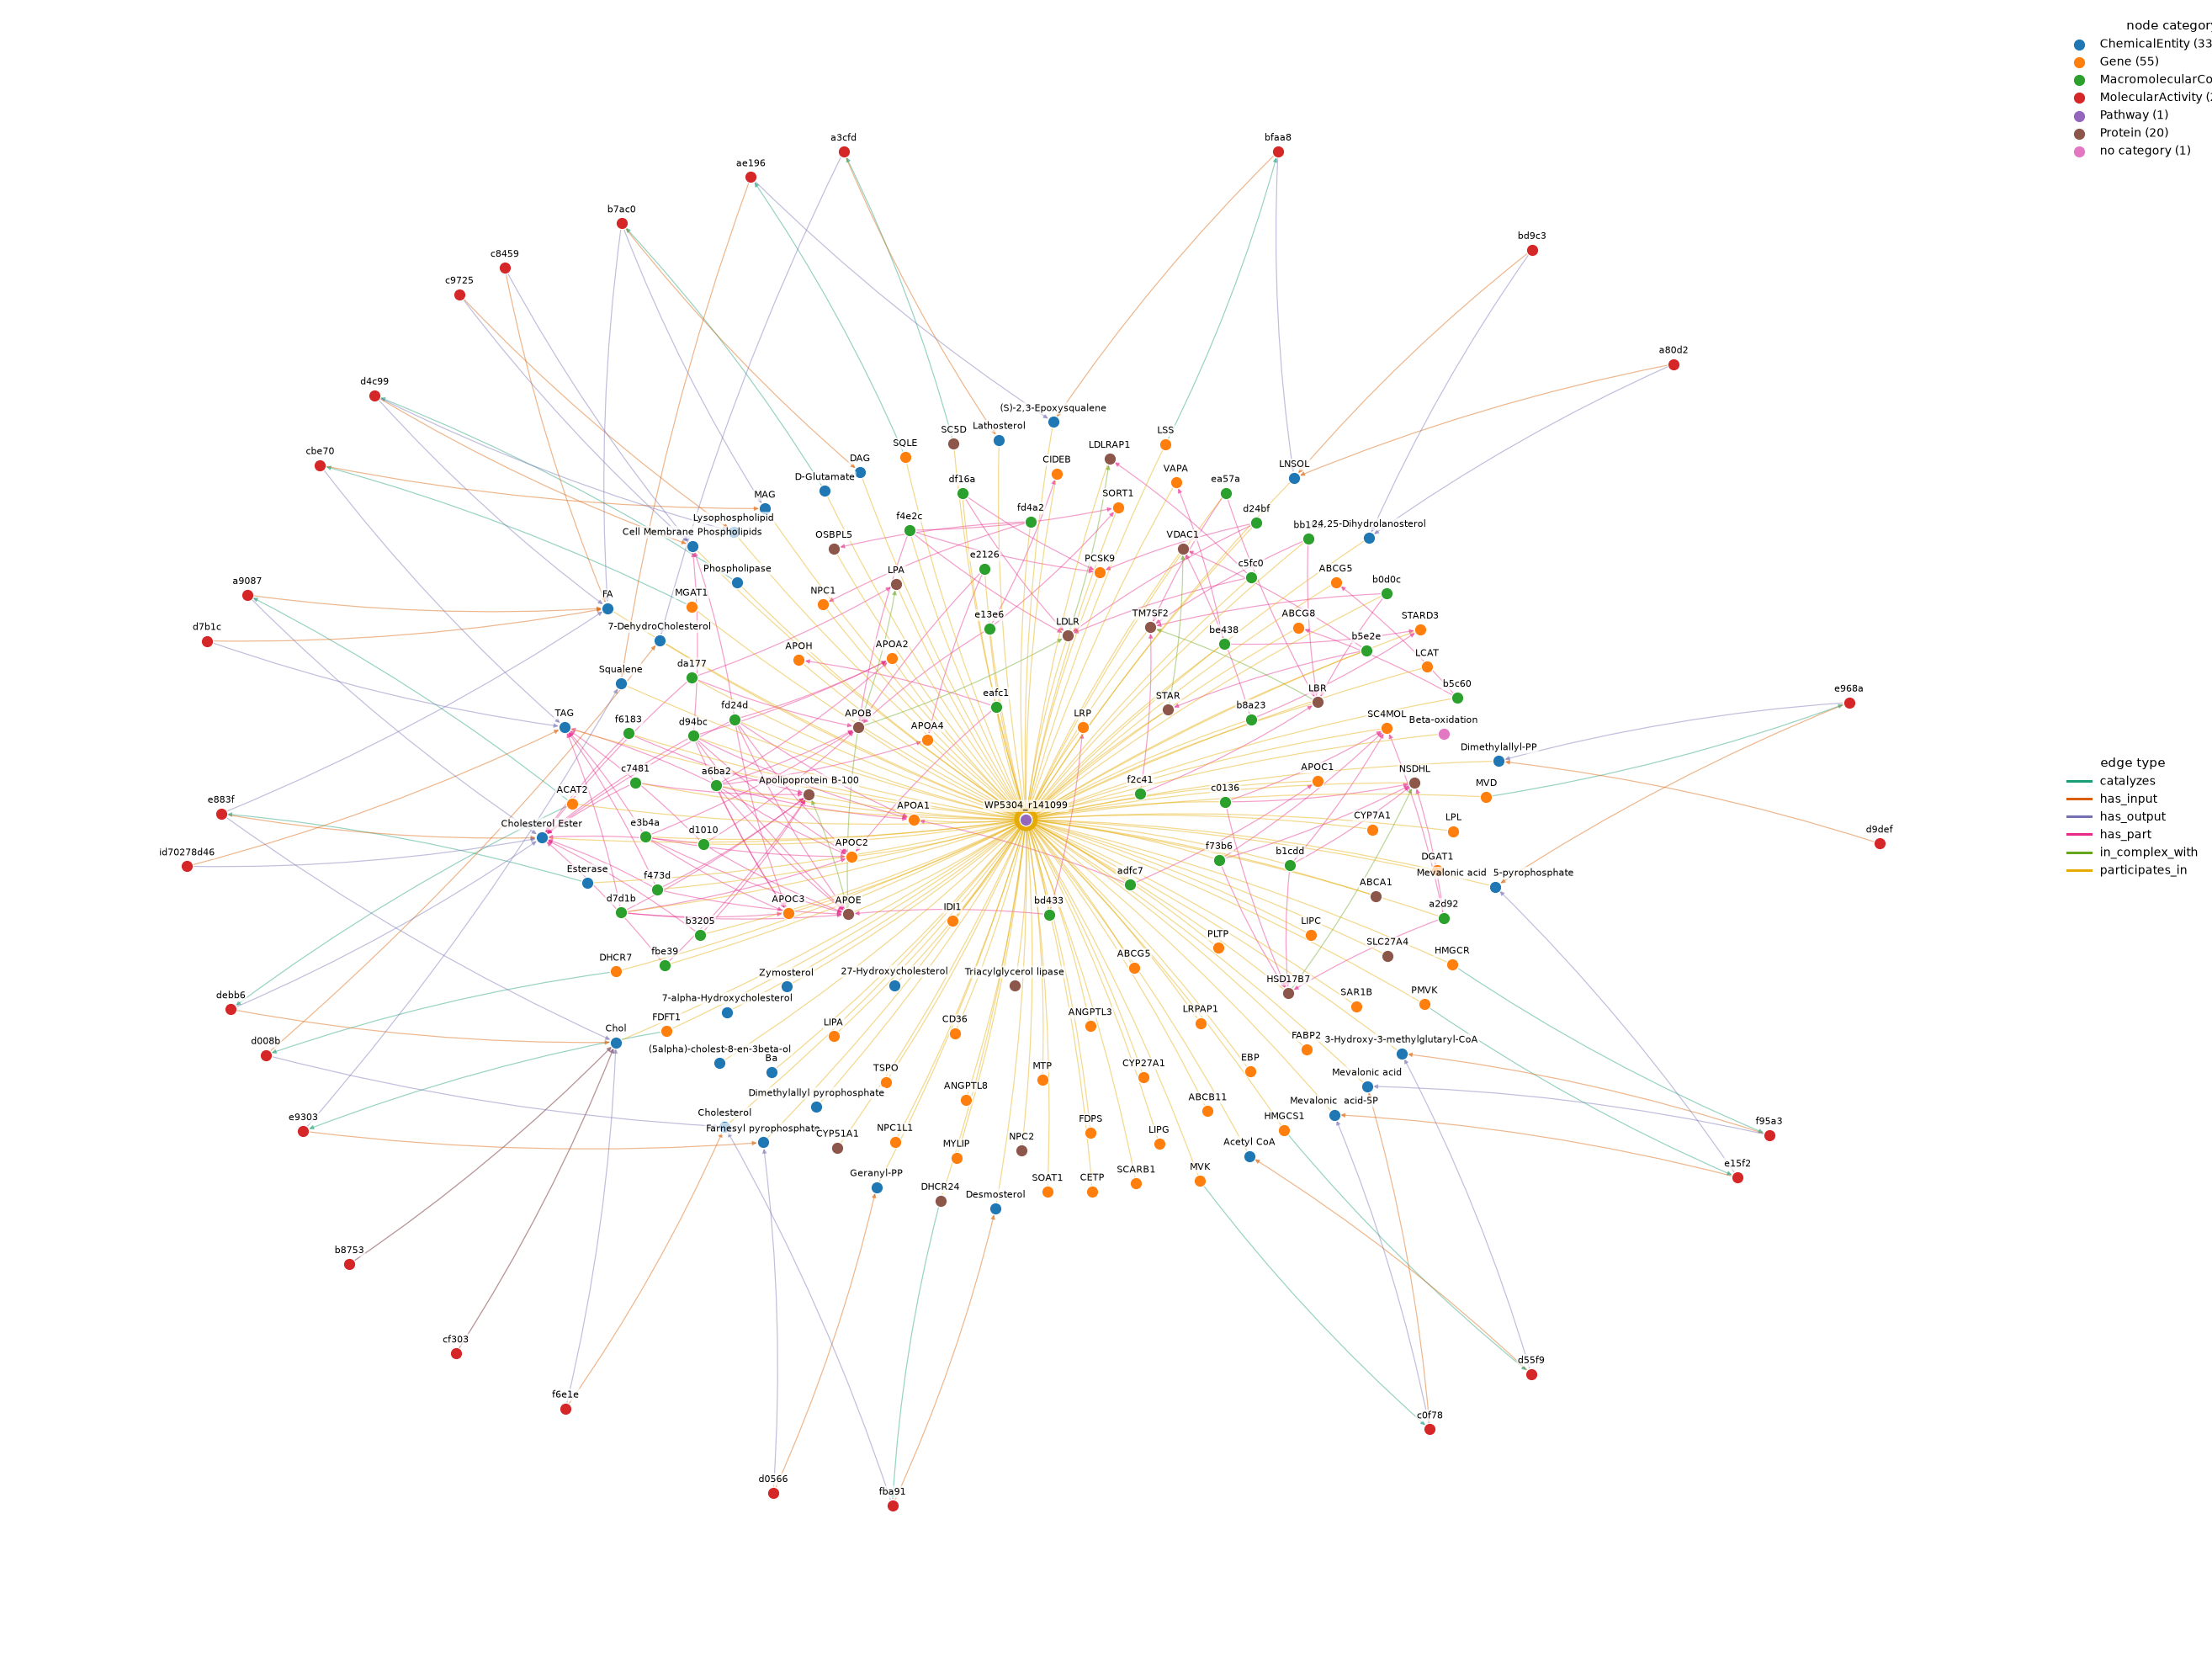

In [41]:
categories = sorted({data["category"] for _, data in network.nodes(data=True)})
edge_types = sorted({data["type"] for _, _, data in network.edges(data=True)})
node_colours = dict(zip(categories, plt.cm.tab10.colors))
edge_colours = dict(zip(edge_types, plt.cm.Dark2.colors))

plt.figure(figsize=(24, 18), dpi=110)
pos = nx.kamada_kawai_layout(network.to_undirected())

for edge_type, colour in edge_colours.items():
    edges = [(u, v) for u, v, data in network.edges(data=True) if data["type"] == edge_type]
    nx.draw_networkx_edges(network, pos, edgelist=edges, edge_color=[colour], width=0.8, alpha=0.45,
                           arrowsize=7, node_size=90, connectionstyle="arc3,rad=0.05")

for category, colour in node_colours.items():
    nodes = [node for node, data in network.nodes(data=True) if data["category"] == category]
    nx.draw_networkx_nodes(network, pos, nodelist=nodes, node_color=[colour], node_size=90,
                           edgecolors="white", linewidths=0.8, label=f"{category} ({len(nodes)})")

label_pos = {node: (x, y + 0.012) for node, (x, y) in pos.items()}
nx.draw_networkx_labels(network, label_pos, labels=dict(network.nodes(data="title")), font_size=7,
                        verticalalignment="bottom",
                        bbox={"boxstyle": "round,pad=0.15", "facecolor": "white", "edgecolor": "none", "alpha": 0.7})

node_legend = plt.legend(title="node category", frameon=False, fontsize=9, title_fontsize=10,
                         loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.gca().add_artist(node_legend)
edge_handles = [Line2D([], [], color=colour, lw=2, label=edge_type) for edge_type, colour in edge_colours.items()]
plt.legend(handles=edge_handles, title="edge type", frameon=False, fontsize=9, title_fontsize=10,
           loc="upper left", bbox_to_anchor=(1.0, 0.55))
plt.axis("off")
plt.tight_layout()
plt.show()

Validation of the generated Biolink PG

In [42]:
# Loading into the biolink model python API
from kgx.transformer import Transformer
from kgx.validator import Validator

nodes, edges = to_kgx(graph=graph, biolink=biolink, folder="output/wp5304-kgx", knowledge_source="infores:wikipathways", local_prefix="wp")
transformer = Transformer()
transformer.transform(input_args={"filename": [str(nodes), str(edges)], "format": "tsv"})
validator = Validator(schema=str(biolink_profile / "biolink-model-4.4.5.yaml"))
validator.validate(transformer.store.graph)
validator.get_errors();

Validating nodes in graph


Validate edges in graph
